# Cognitive Load Prediction — Model Training
### *Branch A · Eye-Tracking Cognitive Load Classification*

---

| Field | Details |
|-------|---------|
| **Project** | Non-Invasive Cognitive Load and Student Engagement Detection |
| **Author** | Yasini Mandara Karunanayake |
| **RGU ID** | 2313473  **IIT ID** 20221151 |
| **Models** | Random Forest · Gradient Boosting · Logistic Regression · SVM |


---

## Notebook Overview

This notebook implements **Stage 2 of Branch A** of the multimodal pipeline.
It loads the preprocessed splits produced by `CL_EDA_Preprocessing.ipynb` and trains four classical ML classifiers for cognitive load classification.

| Step | Description |
|------|-------------|
| 1 | Setup & imports |
| 2 | Load training and test data |
| 3 | Cross-validation setup (5-fold stratified KFold) |
| 4 | Random Forest — baseline CV + GridSearchCV + evaluation |
| 5 | Gradient Boosting — baseline CV + GridSearchCV + evaluation |
| 6 | Logistic Regression — baseline CV + GridSearchCV + evaluation |
| 7 | Support Vector Machine — baseline CV + GridSearchCV + evaluation |
| 8 | Model comparison (Accuracy, Macro F1, ROC-AUC) |
| 9 | All confusion matrices |
| 10 | Learning curves |
| 11 | Save best model (`best_model.pkl`) |


##1. Setup

Install any missing packages and import all required libraries.

- **sklearn** — classifiers, cross-validation, GridSearchCV, metrics
- **imbalanced-learn** — required by the preprocessing notebook (loaded here for safety)
- **joblib** — model serialisation (save/load `.pkl` files)
- **seaborn / matplotlib** — visualisation

In [ ]:
# Install imbalanced-learn if running in a fresh environment
!pip install -q imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Classifiers
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Model selection and tuning
from sklearn.model_selection import (
    cross_val_score, StratifiedKFold, GridSearchCV, learning_curve
)

# Evaluation metrics
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    roc_auc_score, accuracy_score, f1_score
)
from sklearn.preprocessing import label_binarize

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print('All libraries loaded successfully.')

Ready.


## 2. Load Training and Test Data

Load the CSV files produced by `CL_EDA_Preprocessing.ipynb`:

| Variable | File | Description |
|----------|------|-------------|
| `X_train` | `X_train_smote.csv` | SMOTE-balanced features (unscaled) — for tree-based models |
| `X_train_s` | `X_train_smote_scaled.csv` | SMOTE-balanced features (scaled) — for LR and SVM |
| `y_train` | `y_train_smote.csv` | SMOTE-balanced labels |
| `X_test` | `X_test.csv` | Held-out test features (unscaled) |
| `X_test_s` | `X_test_scaled.csv` | Held-out test features (scaled) |
| `y_test` | `y_test.csv` | Held-out test labels — never used during training |

> The test set retains its **original, unbalanced class distribution**  
> to give a realistic estimate of model performance in real-world deployment.

In [ ]:
X_train   = pd.read_csv('X_train_smote.csv')
X_train_s = pd.read_csv('X_train_smote_scaled.csv')
y_train   = pd.read_csv('y_train_smote.csv').squeeze()

X_test    = pd.read_csv('X_test.csv')
X_test_s  = pd.read_csv('X_test_scaled.csv')
y_test    = pd.read_csv('y_test.csv').squeeze()

print(f'Training set (SMOTE): {X_train.shape}')
print(f'Test set (holdout)  : {X_test.shape}')
print()
print('Class distribution — Training (after SMOTE, balanced):')
print(y_train.value_counts().sort_index()
      .rename(index={0: 'Low', 1: 'Medium', 2: 'High'}))
print()
print('Class distribution — Test (original, unbalanced):')
print(y_test.value_counts().sort_index()
      .rename(index={0: 'Low', 1: 'Medium', 2: 'High'}))

Train (SMOTE): (2787, 4)
Test         : (600, 4)

Class distribution — SMOTE Train:
Engagement_Label
Low       929
Medium    929
High      929
Name: count, dtype: int64

Class distribution — Test (untouched):
Engagement_Label
Low       180
Medium    233
High      187
Name: count, dtype: int64


## 3. Cross-Validation Setup

We use **5-fold Stratified K-Fold** cross-validation throughout:

- **Stratified** — each fold preserves the class proportions of the  
  SMOTE-balanced training set, preventing unstable evaluation on unbalanced folds
- **5 folds** — standard trade-off between variance reduction and compute cost
- **shuffle=True** — randomises fold assignment to reduce ordering bias

Cross-validation is used for **model selection and hyperparameter tuning**.  
Final performance is always reported on the held-out test set.

In [ ]:
# 5-fold stratified cross-validation — used inside GridSearchCV for all models
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_cv(model, X, y, name):
    """Run 5-fold CV and print mean accuracy ± std."""
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    print(f"{name:<30}  CV Acc: {scores.mean():.4f} ± {scores.std():.4f}")
    return scores

## 4. Random Forest

**Random Forest** is an ensemble of decision trees trained via bootstrap  
aggregation (bagging). Each tree sees a random subset of training samples  
and features, reducing variance and overfitting.

**Why Random Forest?**  
Ensemble methods have shown strong performance on tabular eye-tracking data  
and provide built-in feature importance scores as an interpretability benefit.

**Tuning strategy:** `GridSearchCV` exhaustively tests all combinations of:

| Parameter | Values tested |
|-----------|---------------|
| `n_estimators` | 100, 200 |
| `max_depth` | None (unlimited), 10, 20 |
| `min_samples_split` | 2, 5 |

### 4.1 Hyperparameter Tuning

In [ ]:
# Baseline CV to measure default performance
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
evaluate_cv(rf, X_train, y_train, 'RandomForest (default)')

# Grid search over hyperparameter combinations
param_grid_rf = {
    'n_estimators':     [100, 200],
    'max_depth':        [None, 10, 20],
    'min_samples_split':[2, 5],
}
gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
gs_rf.fit(X_train, y_train)

print(f'\nBest RF params : {gs_rf.best_params_}')
print(f'Best RF CV acc : {gs_rf.best_score_:.4f}')
best_rf = gs_rf.best_estimator_  # store best model for evaluation

RandomForest (default)        CV Acc: 0.8970 ± 0.0053

Best RF params : {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Best RF CV acc : 0.9010


### 4.2 Test Set Evaluation

The best Random Forest model is evaluated on the held-out test set.  
Feature importances show which eye-tracking metrics the model relies on most.

Random Forest - Test Set
              precision    recall  f1-score   support

         Low       0.88      0.92      0.90       180
      Medium       0.84      0.81      0.82       233
        High       0.88      0.88      0.88       187

    accuracy                           0.86       600
   macro avg       0.87      0.87      0.87       600
weighted avg       0.86      0.86      0.86       600



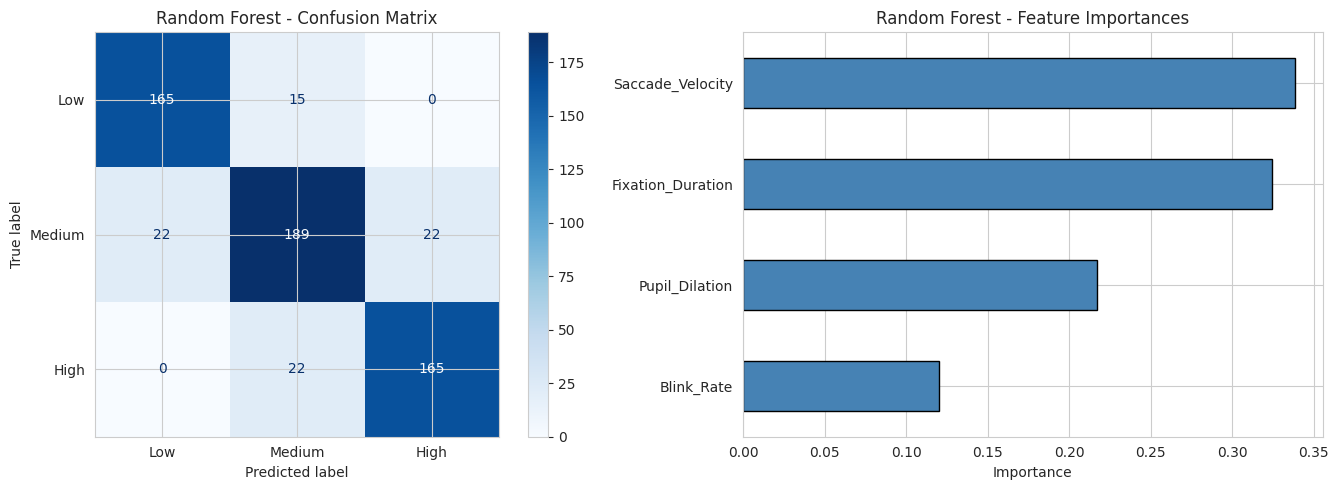

In [ ]:
# Train the best model on the full training set and evaluate on the test set
best_rf.fit(X_train, y_train)
y_pred_rf = best_rf.predict(X_test)

print('Random Forest — Test Set Results')
print('-' * 50)
print(classification_report(y_test, y_pred_rf, target_names=['Low', 'Medium', 'High']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix — shows per-class prediction accuracy
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, display_labels=['Low', 'Medium', 'High'],
    cmap='Blues', ax=axes[0])
axes[0].set_title('Random Forest — Confusion Matrix', fontweight='bold')

# Feature importances — which eye metric matters most?
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
importances.sort_values().plot.barh(ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Random Forest — Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

## 5. Gradient Boosting

**Gradient Boosting** builds trees sequentially, where each new tree corrects  
the errors of the previous one by minimising a differentiable loss function.

**Why Gradient Boosting?**  
The sequential error-correction mechanism can improve performance in regions  
where class distributions overlap (e.g., the Medium engagement boundary),  
which Random Forest's parallel bagging approach may handle less precisely.

**Tuning strategy:**

| Parameter | Values tested |
|-----------|---------------|
| `n_estimators` | 100, 200 |
| `learning_rate` | 0.05, 0.1 |
| `max_depth` | 3, 5 |

### 5.1 Hyperparameter Tuning

In [ ]:
# Baseline CV with default Gradient Boosting parameters
gb = GradientBoostingClassifier(random_state=42)
evaluate_cv(gb, X_train, y_train, 'GradientBoosting (default)')

# Grid search over learning rate, depth, and number of estimators
param_grid_gb = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth':     [3, 5],
}
gs_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
gs_gb.fit(X_train, y_train)

print(f'\nBest GB params : {gs_gb.best_params_}')
print(f'Best GB CV acc : {gs_gb.best_score_:.4f}')
best_gb = gs_gb.best_estimator_

GradientBoosting (default)    CV Acc: 0.9013 ± 0.0072

Best GB params : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best GB CV acc : 0.9013
